# PhoBERT Fine-tuning for Vietnamese Company Review Sentiment

Notebook này fine-tune PhoBERT cho đúng bài toán hiện tại của project:

- **Input**: review công ty tiếng Việt từ `1900_export_reviews.csv`.
- **Label**: 3 lớp `negative / neutral / positive`, sinh bằng weak labelling từ **star rating + keyword/ABSA signal**.
- **Neutral-aware training**: stratified split, class weights, early stopping theo **macro F1**, và optional `neutral_boost` trên validation set.
- **Baseline để so sánh**: `MLP_NeuralNet_Tuned` hiện đang tốt nhất trong report FastText + handcrafted features.

Chạy trên Colab GPU được khuyến nghị: `Runtime -> Change runtime type -> T4 GPU`.

In [ ]:
# Colab dependency setup. Local environments with these packages installed can skip this cell.
import importlib.util
import subprocess
import sys

IN_COLAB = "google.colab" in sys.modules

required = {
    "transformers": "transformers",
    "accelerate": "accelerate",
    "sentencepiece": "sentencepiece",
    "underthesea": "underthesea",
    "sklearn": "scikit-learn",
    "seaborn": "seaborn",
    "tabulate": "tabulate",
    "tqdm": "tqdm",
}

missing = [pip_name for import_name, pip_name in required.items() if importlib.util.find_spec(import_name) is None]
if missing:
    print("Installing:", missing)
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
else:
    print("All required packages are available.")

Installing: ['underthesea']


In [ ]:
from __future__ import annotations

import json
import math
import os
import random
import shutil
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    DataCollatorWithPadding,
    get_linear_schedule_with_warmup,
)
from underthesea import word_tokenize

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
    torch.backends.cuda.matmul.allow_tf32 = True

LABEL_MAP = {"negative": 0, "neutral": 1, "positive": 2}
LABEL_NAMES = {v: k for k, v in LABEL_MAP.items()}
ID2LABEL = {i: LABEL_NAMES[i] for i in range(3)}
LABEL2ID = {name: i for i, name in ID2LABEL.items()}

# Baseline from analysis/report.md, run_20260514_094114.
BASELINE_MLP = {
    "name": "MLP_NeuralNet_Tuned",
    "accuracy": 0.7967,
    "f1_macro": 0.7277,
    "f1_weighted": 0.7951,
    "precision_macro": 0.7317,
    "recall_macro": 0.7241,
    "negative_f1": 0.7765,
    "neutral_f1": 0.5089,
    "positive_f1": 0.8977,
}

# Main knobs. Increase MAX_LEN only if GPU memory allows it.
MODEL_NAME = "vinai/phobert-base-v2"
MAX_LEN = 192
BATCH_SIZE = 16
EPOCHS = 4
PATIENCE = 2
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.10
GRAD_CLIP = 1.0
USE_AMP = device.type == "cuda"
USE_CLASS_WEIGHTS = True
PRESEGMENT_FOR_PHOBERT = True
MAX_EXAMPLES = None  # set to e.g. 1000 for a smoke test, None for the full dataset

IN_COLAB = "google.colab" in sys.modules
OUTPUT_DIR = Path("/content/phobert_outputs") if IN_COLAB else Path("analysis/phobert_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
BEST_MODEL_DIR = OUTPUT_DIR / "best_phobert_model"
print("Output dir:", OUTPUT_DIR)

Device: cuda
GPU: Tesla T4
Output dir: /content/phobert_outputs


## 1. Load Review CSV

Ưu tiên file 10,000 dòng ở `data/raw/1900_export_reviews.csv`. Nếu chạy trên Colab và chưa có file, cell sẽ yêu cầu upload CSV.

In [ ]:
def read_review_csv(path: Path) -> pd.DataFrame:
    encodings = ["utf-8-sig", "utf-8", "cp1258", "latin1"]
    last_error = None
    for enc in encodings:
        try:
            df = pd.read_csv(path, encoding=enc)
            print(f"Read CSV with encoding={enc}")
            return df
        except UnicodeDecodeError as exc:
            last_error = exc
    raise UnicodeDecodeError(
        last_error.encoding,
        last_error.object,
        last_error.start,
        last_error.end,
        f"Could not decode CSV with {encodings}: {last_error.reason}",
    )

def find_review_csv() -> Path | None:
    candidates = [
        Path("data/raw/1900_export_reviews.csv"),
        Path("analysis/1900_export_reviews.csv"),
        Path("/content/1900_export_reviews.csv"),
        Path("/content/data/raw/1900_export_reviews.csv"),
        Path("/content/analysis/1900_export_reviews.csv"),
    ]
    for path in candidates:
        if path.exists() and path.stat().st_size > 0:
            return path
    return None

CSV_PATH = find_review_csv()

if CSV_PATH is None and IN_COLAB:
    from google.colab import files
    print("Upload file 1900_export_reviews.csv")
    uploaded = files.upload()
    if not uploaded:
        raise FileNotFoundError("No CSV uploaded.")
    CSV_PATH = Path(next(iter(uploaded.keys())))

if CSV_PATH is None:
    raise FileNotFoundError("Could not find 1900_export_reviews.csv. Put it under data/raw/ or analysis/.")

raw_df = read_review_csv(CSV_PATH)
print("CSV:", CSV_PATH)
print("Rows:", len(raw_df))
print("Columns:", list(raw_df.columns))
raw_df.head(3)

Upload file 1900_export_reviews.csv


Saving 1900_export_reviews.csv to 1900_export_reviews.csv
Read CSV with encoding=utf-8-sig
CSV: 1900_export_reviews.csv
Rows: 10000
Columns: ['company', 'industry', 'rating', 'title', 'job_title', 'employee_status', 'location', 'date', 'pros', 'cons', 'advice', 'recommends']


,company,industry,rating,title,job_title,employee_status,location,date,pros,cons,advice,recommends
0,KDDI Vietnam,Bưu chính viễn thông,3.0,"Quy trình làm việc rõ ràng, có thể học hỏi nhi...",Nhân viên,Nhân viên hiện tại,Hà Nội,13/02/2023,NaN,"- Nhân viên trẻ, thân thiện- Quy trình làm vi...",NaN,Có
1,KDDI Vietnam,Bưu chính viễn thông,4.0,"Công ty có chính sách lương thưởng rõ ràng, tr...",IT Consultant,Nhân viên hiện tại,Hồ Chí Minh,13/01/2023,NaN,"- Công ty có chính sách lương thưởng rõ ràng, ...",NaN,Có
2,KDDI Vietnam,Bưu chính viễn thông,3.0,Thuộc dạng top trong các công ty Nhật làm về S...,Kỹ sư quy trình/ Process Engineer,Nhân viên hiện tại,Hồ Chí Minh,13/01/2023,NaN,- Thuộc dạng top trong các công ty Nhật làm về...,NaN,Có


## 2. Current Weak Labelling Logic

Đây là bản self-contained của logic trong `src/training/labeling.py`: rating tạo nhãn ban đầu, sau đó keyword + ABSA opinion lexicon sửa các case rating-text mismatch. Neutral được giữ là lớp riêng, không gộp vào positive/negative.

Usable reviews: 10,000
Re-labelled vs rating-only: 1,469 (14.7%)

Label distribution:
label_name
negative    2370
neutral     1904
positive    5726
Name: count, dtype: int64

Label source distribution:
label_source
rating                                7212
neutral_unchanged                     1319
neutral_to_positive_absa               773
negative_to_neutral_absa_conflict      524
negative_to_positive_absa_override      94
positive_to_neutral_absa_conflict       61
neutral_to_negative_absa                16
positive_to_negative_absa_override       1
Name: count, dtype: int64


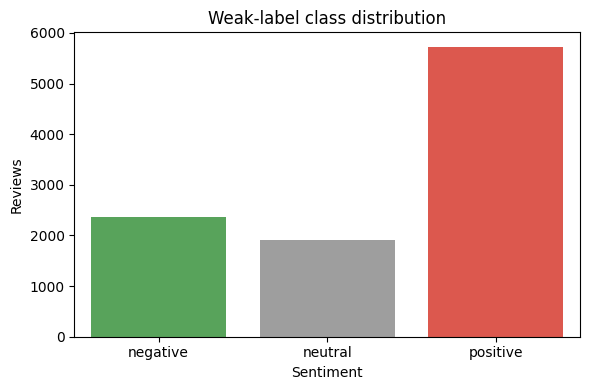

In [ ]:

def rating_to_sentiment(rating: float | None) -> int | None:
    if rating is None or pd.isna(rating):
        return None
    rating = float(rating)
    if rating <= 2.0:
        return LABEL_MAP["negative"]
    if rating <= 3.0:
        return LABEL_MAP["neutral"]
    return LABEL_MAP["positive"]

_NEGATIVE_KEYWORDS = [
    'tệ',
    'kém',
    'tồi',
    'chán',
    'thất vọng',
    'không tốt',
    'lương thấp',
    'quá tải',
    'áp lực',
    'bóc lột',
    'không công bằng',
    'thiếu chuyên nghiệp',
    'hay thay đổi',
    'không ổn định',
    'môi trường độc hại',
    'overtime',
    'không có cơ hội',
    'trì trệ',
    'lãnh đạo kém',
    'quan liêu',
    'không phù hợp',
    'không xứng đáng',
    'không minh bạch',
]

_POSITIVE_KEYWORDS = [
    'tuyệt vời',
    'xuất sắc',
    'tốt',
    'chuyên nghiệp',
    'hài lòng',
    'lương cao',
    'phúc lợi',
    'cơ hội',
    'phát triển',
    'năng động',
    'thân thiện',
    'hỗ trợ',
    'linh hoạt',
    'ổn định',
    'học hỏi',
    'sáng tạo',
    'đãi ngộ tốt',
    'đồng nghiệp tốt',
    'cân bằng',
    'không phàn nàn',
    'không có gì phàn nàn',
    'không có gì để chê',
    'không có gì cần phàn nàn',
    'chịu khó',
    'kiên trì',
]

_ABSA_POSITIVE = [
    'tốt',
    'tuyệt',
    'ổn',
    'tích cực',
    'nhiệt tình',
    'rõ ràng',
    'minh bạch',
    'công bằng',
    'hỗ trợ',
    'vui',
    'thân thiện',
    'chuyên nghiệp',
    'năng động',
    'cởi mở',
    'hợp lý',
    'xứng đáng',
    'phù hợp',
    'ổn định',
    'hiệu quả',
    'tuyệt vời',
    'hài lòng',
    'thoải mái',
    'cạnh tranh',
    'tận tâm',
    'quan tâm',
    'không phàn nàn',
    'không có gì phàn nàn',
    'không có gì để chê',
    'chịu khó',
    'kiên trì',
]

_ABSA_NEGATIVE = [
    'không tốt',
    'không ổn',
    'không phù hợp',
    'không xứng đáng',
    'tệ',
    'kém',
    'chậm',
    'áp lực',
    'stress',
    'thấp',
    'thiếu',
    'ràng buộc',
    'bất công',
    'drama',
    'độc đoán',
    'toxic',
    'khắc khe',
    'ì ạch',
    'trễ',
    'cũ kỹ',
    'thất vọng',
    'khó khăn',
    'quá tải',
    'mệt',
    'chán',
    'không minh bạch',
    'không công bằng',
    'không hợp lý',
]

def _keyword_score(text: str) -> float:
    if not text or pd.isna(text):
        return 0.0
    t = str(text).lower()
    pos = sum(1 for kw in _POSITIVE_KEYWORDS if kw in t)
    neg = sum(1 for kw in _NEGATIVE_KEYWORDS if kw in t)
    return float(pos - neg)

def _absa_score(title: str, pros: str, cons: str, advice: str) -> float:
    def _field_score(text: str, weight: float = 1.0) -> float:
        if not text or pd.isna(text):
            return 0.0
        t = str(text).lower()
        pos = sum(1 for w in _ABSA_POSITIVE if w in t)
        neg = sum(1 for w in _ABSA_NEGATIVE if w in t)
        return (pos - neg) * weight

    # Current repo logic: newer CSV often stores the full body in `cons`,
    # so `cons` is not given an automatic negative-heavy weight.
    return (
        _field_score(title, 1.0)
        + _field_score(pros, 1.0)
        + _field_score(cons, 1.0)
        + _field_score(advice, 0.5)
    )

def weak_label_combine(rating_label: int, pros: str, cons: str, advice: str, title: str = "") -> tuple[int, str]:
    all_text = " ".join(str(x) for x in [title, pros, cons, advice])
    combined = _keyword_score(all_text) + _absa_score(title, pros, cons, advice)

    if rating_label == LABEL_MAP["neutral"]:
        if combined <= -2.5:
            return LABEL_MAP["negative"], "neutral_to_negative_absa"
        if combined >= 2.5:
            return LABEL_MAP["positive"], "neutral_to_positive_absa"
        return rating_label, "neutral_unchanged"

    if rating_label == LABEL_MAP["positive"] and combined <= -5:
        return LABEL_MAP["negative"], "positive_to_negative_absa_override"
    if rating_label == LABEL_MAP["positive"] and combined <= -2:
        return LABEL_MAP["neutral"], "positive_to_neutral_absa_conflict"

    if rating_label == LABEL_MAP["negative"] and combined >= 5:
        return LABEL_MAP["positive"], "negative_to_positive_absa_override"
    if rating_label == LABEL_MAP["negative"] and combined >= 2:
        return LABEL_MAP["neutral"], "negative_to_neutral_absa_conflict"

    return rating_label, "rating"

def make_labeled_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    records = []
    for _, row in df.iterrows():
        parts = []
        for col in ["title", "pros", "cons", "advice"]:
            val = row.get(col, "")
            if pd.notna(val) and str(val).strip():
                parts.append(str(val).strip())
        text = " ".join(parts)
        if not text.strip():
            continue

        rating_label = rating_to_sentiment(row.get("rating"))
        if rating_label is None:
            continue

        title = str(row.get("title") or "")
        pros = str(row.get("pros") or "")
        cons = str(row.get("cons") or "")
        advice = str(row.get("advice") or "")
        label, label_source = weak_label_combine(rating_label, pros, cons, advice, title=title)

        records.append({
            "text": text,
            "rating": row.get("rating"),
            "rating_label": rating_label,
            "label_id": label,
            "label_name": LABEL_NAMES[label],
            "label_source": label_source,
            "company": row.get("company", ""),
            "industry": row.get("industry", ""),
        })

    return pd.DataFrame(records)

labeled_df = make_labeled_dataframe(raw_df)
if MAX_EXAMPLES is not None:
    labeled_df = labeled_df.sample(n=min(MAX_EXAMPLES, len(labeled_df)), random_state=SEED).reset_index(drop=True)

changed = labeled_df["label_id"] != labeled_df["rating_label"]
print(f"Usable reviews: {len(labeled_df):,}")
print(f"Re-labelled vs rating-only: {changed.sum():,} ({changed.mean() * 100:.1f}%)")
print("\nLabel distribution:")
print(labeled_df["label_name"].value_counts().reindex(["negative", "neutral", "positive"]))
print("\nLabel source distribution:")
print(labeled_df["label_source"].value_counts())

fig, ax = plt.subplots(figsize=(6, 4))
order = ["negative", "neutral", "positive"]
sns.countplot(data=labeled_df, x="label_name", order=order, ax=ax, palette=["#F44336", "#9E9E9E", "#4CAF50"], hue="label_name", legend=False)
ax.set_title("Weak-label class distribution")
ax.set_xlabel("Sentiment")
ax.set_ylabel("Reviews")
plt.tight_layout()
plt.show()

## 3. PhoBERT Pre-segmentation

PhoBERT works best with Vietnamese word-segmented text. We use `underthesea.word_tokenize(..., format="text")`, which turns phrases like `môi trường` into `môi_trường` before BPE tokenization.

In [ ]:
def segment_for_phobert(text: str) -> str:
    text = str(text).replace("\n", " ").strip()
    if not text:
        return ""
    if not PRESEGMENT_FOR_PHOBERT:
        return text
    try:
        return word_tokenize(text, format="text")
    except Exception:
        # Keep the run alive if a single noisy review breaks the segmenter.
        return text

cache_path = OUTPUT_DIR / f"segmented_reviews_{len(labeled_df)}_{'seg' if PRESEGMENT_FOR_PHOBERT else 'raw'}.csv"
if cache_path.exists():
    segmented_df = pd.read_csv(cache_path)
    print("Loaded segmentation cache:", cache_path)
else:
    segmented_df = labeled_df.copy()
    tqdm.pandas(desc="Segmenting")
    segmented_df["text_phobert"] = segmented_df["text"].progress_apply(segment_for_phobert)
    segmented_df.to_csv(cache_path, index=False, encoding="utf-8-sig")
    print("Saved segmentation cache:", cache_path)

segmented_df[["text", "text_phobert", "label_name"]].head(3)

Segmenting:   0%|          | 0/10000 [00:00<?, ?it/s]

Saved segmentation cache: /content/phobert_outputs/segmented_reviews_10000_seg.csv


,text,text_phobert,label_name
0,"Quy trình làm việc rõ ràng, có thể học hỏi nhi...","Quy_trình làm_việc rõ_ràng , có_thể học_hỏi nh...",positive
1,"Công ty có chính sách lương thưởng rõ ràng, tr...","Công_ty có chính_sách lương_thưởng rõ_ràng , t...",positive
2,Thuộc dạng top trong các công ty Nhật làm về S...,Thuộc dạng top trong các công_ty Nhật làm về S...,neutral


## 4. Stratified 70/15/15 Split

Giữ tỉ lệ 3 lớp trong train/validation/test để so sánh công bằng với pipeline hiện tại.

In [ ]:
train_df, temp_df = train_test_split(
    segmented_df,
    test_size=0.30,
    random_state=SEED,
    stratify=segmented_df["label_id"],
)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_df["label_id"],
)

for name, split_df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    counts = split_df["label_name"].value_counts().reindex(["negative", "neutral", "positive"])
    print(name, len(split_df))
    print(counts.to_string())
    print()

train 7000
label_name
negative    1659
neutral     1333
positive    4008

val 1500
label_name
negative    355
neutral     286
positive    859

test 1500
label_name
negative    356
neutral     285
positive    859



## 5. Tokenizer, Dataset, Dataloaders

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class ReviewDataset(Dataset):
    def __init__(self, frame: pd.DataFrame):
        self.texts = frame["text_phobert"].astype(str).tolist()
        self.labels = frame["label_id"].astype(int).tolist()

    def __len__(self) -> int:
        return len(self.labels)

    def __getitem__(self, idx: int) -> dict[str, torch.Tensor]:
        encoded = tokenizer(
            self.texts[idx],
            max_length=MAX_LEN,
            truncation=True,
            padding=False,
        )
        encoded["labels"] = self.labels[idx]
        return encoded

collator = DataCollatorWithPadding(tokenizer=tokenizer)
train_loader = DataLoader(ReviewDataset(train_df), batch_size=BATCH_SIZE, shuffle=True, collate_fn=collator, num_workers=0)
val_loader = DataLoader(ReviewDataset(val_df), batch_size=BATCH_SIZE * 2, shuffle=False, collate_fn=collator, num_workers=0)
test_loader = DataLoader(ReviewDataset(test_df), batch_size=BATCH_SIZE * 2, shuffle=False, collate_fn=collator, num_workers=0)

batch = next(iter(train_loader))
print({k: tuple(v.shape) for k, v in batch.items()})

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/678 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

{'input_ids': (16, 151), 'attention_mask': (16, 151), 'labels': (16,)}


## 6. Model Setup

Training objective dùng `CrossEntropyLoss(weight=class_weights)` để giảm việc model bỏ qua lớp neutral. Early stopping sẽ theo **validation macro F1**, không theo accuracy.

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    id2label=ID2LABEL,
    label2id=LABEL2ID,
).to(device)

classes = np.array([0, 1, 2])
weights = compute_class_weight(class_weight="balanced", classes=classes, y=train_df["label_id"].values)
class_weights = torch.tensor(weights, dtype=torch.float32, device=device)
print("Class weights:", {LABEL_NAMES[i]: round(float(w), 4) for i, w in enumerate(class_weights)})

loss_fn = nn.CrossEntropyLoss(weight=class_weights if USE_CLASS_WEIGHTS else None)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
num_training_steps = len(train_loader) * EPOCHS
num_warmup_steps = int(num_training_steps * WARMUP_RATIO)
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps, num_training_steps)
scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)
print("Training steps:", num_training_steps, "warmup:", num_warmup_steps, "AMP:", USE_AMP)

pytorch_model.bin:   0%|          | 0.00/540M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: vinai/phobert-base-v2
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


model.safetensors:   0%|          | 0.00/540M [00:00<?, ?B/s]

Class weights: {'negative': 1.4065, 'neutral': 1.7504, 'positive': 0.5822}
Training steps: 1752 warmup: 175 AMP: True


/tmp/ipykernel_2492/3748251290.py:18: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)


## 7. Train and Validate

In [ ]:
def move_batch(batch: dict[str, torch.Tensor]) -> tuple[dict[str, torch.Tensor], torch.Tensor]:
    labels = batch.pop("labels").to(device)
    inputs = {k: v.to(device) for k, v in batch.items()}
    return inputs, labels

def train_one_epoch() -> float:
    model.train()
    total_loss = 0.0
    progress = tqdm(train_loader, leave=False, desc="train")
    for batch in progress:
        optimizer.zero_grad(set_to_none=True)
        inputs, labels = move_batch(batch)
        with torch.cuda.amp.autocast(enabled=USE_AMP):
            logits = model(**inputs).logits
            loss = loss_fn(logits, labels)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()
        total_loss += float(loss.item())
        progress.set_postfix(loss=f"{loss.item():.4f}")
    return total_loss / max(len(train_loader), 1)

@torch.no_grad()
def predict_logits(loader: DataLoader) -> tuple[np.ndarray, np.ndarray, float]:
    model.eval()
    all_logits, all_labels = [], []
    total_loss = 0.0
    for batch in tqdm(loader, leave=False, desc="eval"):
        inputs, labels = move_batch(batch)
        logits = model(**inputs).logits
        loss = loss_fn(logits, labels)
        total_loss += float(loss.item())
        all_logits.append(logits.detach().cpu().numpy())
        all_labels.append(labels.detach().cpu().numpy())
    return np.vstack(all_logits), np.concatenate(all_labels), total_loss / max(len(loader), 1)

def metrics_from_predictions(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    report = classification_report(
        y_true,
        y_pred,
        labels=[0, 1, 2],
        target_names=[LABEL_NAMES[i] for i in [0, 1, 2]],
        output_dict=True,
        zero_division=0,
    )
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "f1_macro": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
        "f1_weighted": float(f1_score(y_true, y_pred, average="weighted", zero_division=0)),
        "precision_macro": float(precision_score(y_true, y_pred, average="macro", zero_division=0)),
        "recall_macro": float(recall_score(y_true, y_pred, average="macro", zero_division=0)),
        "negative_f1": float(report["negative"]["f1-score"]),
        "neutral_f1": float(report["neutral"]["f1-score"]),
        "positive_f1": float(report["positive"]["f1-score"]),
        "classification_report": report,
        "confusion_matrix": confusion_matrix(y_true, y_pred, labels=[0, 1, 2]).tolist(),
    }

def evaluate_loader(loader: DataLoader) -> tuple[dict, float, np.ndarray, np.ndarray]:
    logits, y_true, loss = predict_logits(loader)
    y_pred = logits.argmax(axis=1)
    return metrics_from_predictions(y_true, y_pred), loss, logits, y_true

history = []
best_val_f1 = -1.0
bad_epochs = 0
start = time.time()

for epoch in range(1, EPOCHS + 1):
    train_loss = train_one_epoch()
    val_metrics, val_loss, _, _ = evaluate_loader(val_loader)
    row = {
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "val_accuracy": val_metrics["accuracy"],
        "val_f1_macro": val_metrics["f1_macro"],
        "val_neutral_f1": val_metrics["neutral_f1"],
    }
    history.append(row)
    print(
        f"Epoch {epoch}: train_loss={train_loss:.4f} val_loss={val_loss:.4f} "
        f"val_acc={val_metrics['accuracy']:.4f} val_macro_f1={val_metrics['f1_macro']:.4f} "
        f"val_neutral_f1={val_metrics['neutral_f1']:.4f}"
    )

    if val_metrics["f1_macro"] > best_val_f1:
        best_val_f1 = val_metrics["f1_macro"]
        bad_epochs = 0
        BEST_MODEL_DIR.mkdir(parents=True, exist_ok=True)
        model.save_pretrained(BEST_MODEL_DIR)
        tokenizer.save_pretrained(BEST_MODEL_DIR)
        print("  saved best model")
    else:
        bad_epochs += 1
        if bad_epochs >= PATIENCE:
            print("Early stopping.")
            break

elapsed = time.time() - start
print(f"Training finished in {elapsed / 60:.1f} minutes. Best validation macro F1={best_val_f1:.4f}")

history_df = pd.DataFrame(history)
history_df.to_csv(OUTPUT_DIR / "phobert_history.csv", index=False)
history_df

train:   0%|          | 0/438 [00:00<?, ?it/s]

/tmp/ipykernel_2492/200556660.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


eval:   0%|          | 0/47 [00:00<?, ?it/s]

Epoch 1: train_loss=0.7405 val_loss=0.6270 val_acc=0.8047 val_macro_f1=0.7344 val_neutral_f1=0.5057


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

train:   0%|          | 0/438 [00:00<?, ?it/s]

/tmp/ipykernel_2492/200556660.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


eval:   0%|          | 0/47 [00:00<?, ?it/s]

Epoch 4: train_loss=0.3115 val_loss=0.6209 val_acc=0.8373 val_macro_f1=0.7880 val_neutral_f1=0.6050
Training finished in 6.2 minutes. Best validation macro F1=0.7989


,epoch,train_loss,val_loss,val_accuracy,val_f1_macro,val_neutral_f1
0,1,0.740520,0.626997,0.804667,0.734396,0.505660
1,2,0.513171,0.548772,0.832000,0.788042,0.615630
2,3,0.392631,0.564096,0.841333,0.798916,0.633441
3,4,0.311542,0.620879,0.837333,0.787980,0.605042


## 8. Tune Neutral Boost on Validation

Neutral là lớp khó nhất trong pipeline hiện tại. Cell này tune một hệ số nhân xác suất cho lớp neutral trên validation set, tương tự `NeutralBoost` trong training pipeline hiện có.

In [ ]:
# Reload the best checkpoint before tuning/evaluating.
model = AutoModelForSequenceClassification.from_pretrained(BEST_MODEL_DIR).to(device)

def softmax_np(logits: np.ndarray) -> np.ndarray:
    logits = logits - logits.max(axis=1, keepdims=True)
    exp = np.exp(logits)
    return exp / exp.sum(axis=1, keepdims=True)

def predict_with_neutral_boost(probs: np.ndarray, boost: float) -> np.ndarray:
    adjusted = probs.copy()
    adjusted[:, LABEL_MAP["neutral"]] *= boost
    return adjusted.argmax(axis=1)

val_metrics, val_loss, val_logits, val_y = evaluate_loader(val_loader)
val_probs = softmax_np(val_logits)

boost_rows = []
for boost in np.round(np.arange(0.8, 2.61, 0.1), 2):
    pred = predict_with_neutral_boost(val_probs, float(boost))
    m = metrics_from_predictions(val_y, pred)
    boost_rows.append({
        "neutral_boost": float(boost),
        "f1_macro": m["f1_macro"],
        "accuracy": m["accuracy"],
        "neutral_f1": m["neutral_f1"],
    })
boost_df = pd.DataFrame(boost_rows).sort_values(["f1_macro", "neutral_f1"], ascending=False)
best_neutral_boost = float(boost_df.iloc[0]["neutral_boost"])
print("Base validation:", {k: round(val_metrics[k], 4) for k in ["accuracy", "f1_macro", "neutral_f1"]})
print("Best neutral boost:", best_neutral_boost)
boost_df.head(10)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

eval:   0%|          | 0/47 [00:00<?, ?it/s]

Base validation: {'accuracy': 0.8413, 'f1_macro': 0.7989, 'neutral_f1': 0.6334}
Best neutral boost: 0.9


,neutral_boost,f1_macro,accuracy,neutral_f1
1,0.9,0.802239,0.845333,0.638436
3,1.1,0.801878,0.843333,0.640000
0,0.8,0.799147,0.843333,0.631579
2,1.0,0.798916,0.841333,0.633441
4,1.2,0.798452,0.838667,0.633071
5,1.3,0.796463,0.836667,0.630094
16,2.4,0.794677,0.830667,0.635015
13,2.1,0.794556,0.832000,0.632530
6,1.4,0.794482,0.834667,0.627145
12,2.0,0.794224,0.832000,0.631420


## 9. Test Set Evaluation and Baseline Comparison

In [ ]:
test_metrics, test_loss, test_logits, test_y = evaluate_loader(test_loader)
test_probs = softmax_np(test_logits)
test_pred = test_logits.argmax(axis=1)
boosted_test_pred = predict_with_neutral_boost(test_probs, best_neutral_boost)
boosted_test_metrics = metrics_from_predictions(test_y, boosted_test_pred)

summary_rows = [
    {"model": BASELINE_MLP["name"], **{k: BASELINE_MLP[k] for k in ["accuracy", "f1_macro", "f1_weighted", "precision_macro", "recall_macro", "negative_f1", "neutral_f1", "positive_f1"]}},
    {"model": "PhoBERT", **{k: test_metrics[k] for k in ["accuracy", "f1_macro", "f1_weighted", "precision_macro", "recall_macro", "negative_f1", "neutral_f1", "positive_f1"]}},
    {"model": f"PhoBERT_NeutralBoost_{best_neutral_boost:.1f}", **{k: boosted_test_metrics[k] for k in ["accuracy", "f1_macro", "f1_weighted", "precision_macro", "recall_macro", "negative_f1", "neutral_f1", "positive_f1"]}},
]
summary_df = pd.DataFrame(summary_rows)
for col in summary_df.columns:
    if col != "model":
        summary_df[col] = summary_df[col].astype(float).round(4)
summary_df.to_csv(OUTPUT_DIR / "phobert_vs_mlp_summary.csv", index=False)
summary_df

eval:   0%|          | 0/47 [00:00<?, ?it/s]

,model,accuracy,f1_macro,f1_weighted,precision_macro,recall_macro,negative_f1,neutral_f1,positive_f1
0,MLP_NeuralNet_Tuned,0.7967,0.7277,0.7951,0.7317,0.7241,0.7765,0.5089,0.8977
1,PhoBERT,0.8220,0.7781,0.8269,0.7742,0.7847,0.8555,0.5825,0.8962
2,PhoBERT_NeutralBoost_0.9,0.8240,0.7793,0.8284,0.7757,0.7851,0.8555,0.5840,0.8983


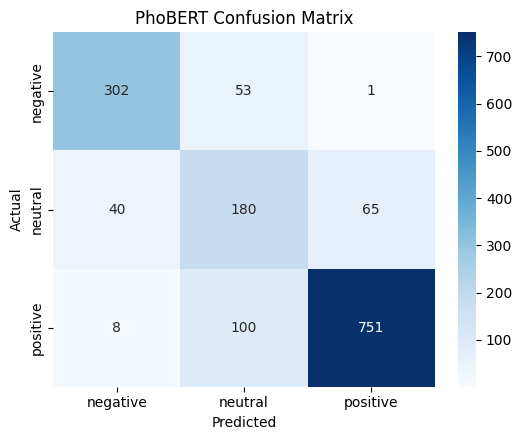

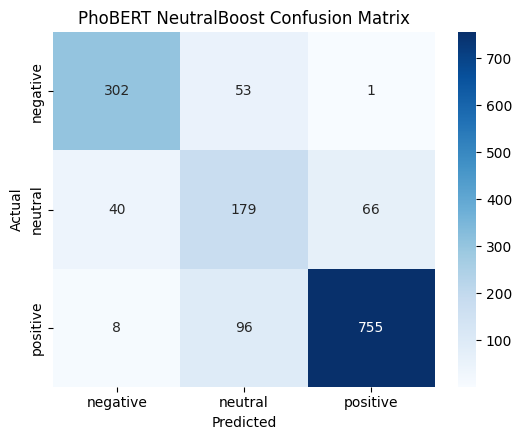

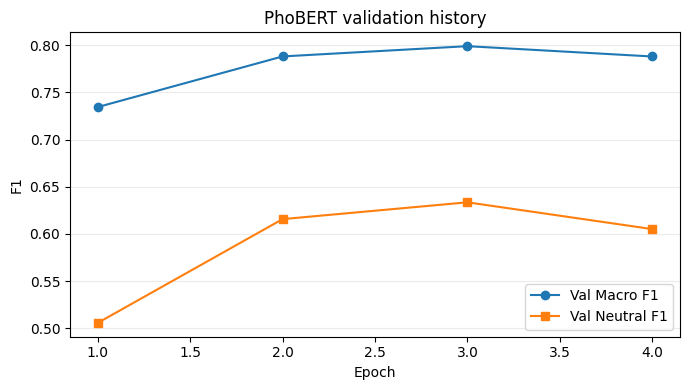

In [ ]:
def plot_confusion(cm: list[list[int]], title: str, path: Path):
    fig, ax = plt.subplots(figsize=(5.5, 4.5))
    sns.heatmap(
        np.array(cm),
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=[LABEL_NAMES[i] for i in [0, 1, 2]],
        yticklabels=[LABEL_NAMES[i] for i in [0, 1, 2]],
        ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    plt.tight_layout()
    fig.savefig(path, dpi=160, bbox_inches="tight")
    plt.show()

plot_confusion(test_metrics["confusion_matrix"], "PhoBERT Confusion Matrix", OUTPUT_DIR / "phobert_confusion_matrix.png")
plot_confusion(boosted_test_metrics["confusion_matrix"], "PhoBERT NeutralBoost Confusion Matrix", OUTPUT_DIR / "phobert_neutralboost_confusion_matrix.png")

fig, ax = plt.subplots(figsize=(7, 4))
if not history_df.empty:
    ax.plot(history_df["epoch"], history_df["val_f1_macro"], marker="o", label="Val Macro F1")
    ax.plot(history_df["epoch"], history_df["val_neutral_f1"], marker="s", label="Val Neutral F1")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("F1")
    ax.set_title("PhoBERT validation history")
    ax.grid(True, axis="y", alpha=0.25)
    ax.legend()
    plt.tight_layout()
    fig.savefig(OUTPUT_DIR / "phobert_history.png", dpi=160, bbox_inches="tight")
    plt.show()

## 10. Save Experiment Report

Sau khi chạy xong, gửi lại `phobert_report.md` hoặc paste bảng summary để cập nhật report chính của project.

In [ ]:
relabel_count = int((labeled_df["label_id"] != labeled_df["rating_label"]).sum())
relabel_pct = float((labeled_df["label_id"] != labeled_df["rating_label"]).mean() * 100)
class_dist = labeled_df["label_name"].value_counts().reindex(["negative", "neutral", "positive"]).fillna(0).astype(int)

payload = {
    "model_name": MODEL_NAME,
    "csv_path": str(CSV_PATH),
    "sample_count": int(len(labeled_df)),
    "relabel_count": relabel_count,
    "relabel_pct": relabel_pct,
    "class_distribution": class_dist.to_dict(),
    "split": {"train": int(len(train_df)), "val": int(len(val_df)), "test": int(len(test_df))},
    "config": {
        "max_len": MAX_LEN,
        "batch_size": BATCH_SIZE,
        "epochs_requested": EPOCHS,
        "epochs_completed": int(len(history_df)),
        "learning_rate": LEARNING_RATE,
        "class_weights": USE_CLASS_WEIGHTS,
        "presegment_for_phobert": PRESEGMENT_FOR_PHOBERT,
        "best_neutral_boost": best_neutral_boost,
    },
    "baseline_mlp": BASELINE_MLP,
    "phobert": {k: v for k, v in test_metrics.items() if k != "classification_report"},
    "phobert_neutralboost": {k: v for k, v in boosted_test_metrics.items() if k != "classification_report"},
}

with open(OUTPUT_DIR / "phobert_results.json", "w", encoding="utf-8") as f:
    json.dump(payload, f, ensure_ascii=False, indent=2)

best_row = summary_df.sort_values("f1_macro", ascending=False).iloc[0]
delta_macro = float(best_row["f1_macro"] - BASELINE_MLP["f1_macro"])
delta_acc = float(best_row["accuracy"] - BASELINE_MLP["accuracy"])

report = f"""# PhoBERT Experiment Report

## Setup

- Model: `{MODEL_NAME}`
- Dataset: `{CSV_PATH}`
- Usable reviews: {len(labeled_df):,}
- Weak-label relabelled reviews: {relabel_count:,} ({relabel_pct:.1f}%)
- Labels: negative / neutral / positive
- Split: train={len(train_df):,}, val={len(val_df):,}, test={len(test_df):,}
- Selection metric: validation macro F1
- Neutral handling: class weights + validation-tuned neutral boost `{best_neutral_boost:.1f}`

## Class Distribution

| Class | Count |
|---|---:|
| Negative | {class_dist['negative']:,} |
| Neutral | {class_dist['neutral']:,} |
| Positive | {class_dist['positive']:,} |

## Test Comparison

{summary_df.to_markdown(index=False)}

## Interpretation

Best test model by macro F1: **{best_row['model']}**.
Compared with current MLP baseline, delta macro F1 = **{delta_macro:+.4f}**, delta accuracy = **{delta_acc:+.4f}**.

Neutral remains the key diagnostic class, so prefer the model with stronger macro F1 and neutral F1 unless accuracy drops too sharply.
"""

report_path = OUTPUT_DIR / "phobert_report.md"
report_path.write_text(report, encoding="utf-8")
print(report)
print("\nSaved:", report_path)

# PhoBERT Experiment Report

## Setup

- Model: `vinai/phobert-base-v2`
- Dataset: `1900_export_reviews.csv`
- Usable reviews: 10,000
- Weak-label relabelled reviews: 1,469 (14.7%)
- Labels: negative / neutral / positive
- Split: train=7,000, val=1,500, test=1,500
- Selection metric: validation macro F1
- Neutral handling: class weights + validation-tuned neutral boost `0.9`

## Class Distribution

| Class | Count |
|---|---:|
| Negative | 2,370 |
| Neutral | 1,904 |
| Positive | 5,726 |

## Test Comparison

| model                    |   accuracy |   f1_macro |   f1_weighted |   precision_macro |   recall_macro |   negative_f1 |   neutral_f1 |   positive_f1 |
|:-------------------------|-----------:|-----------:|--------------:|------------------:|---------------:|--------------:|-------------:|--------------:|
| MLP_NeuralNet_Tuned      |     0.7967 |     0.7277 |        0.7951 |            0.7317 |         0.7241 |        0.7765 |       0.5089 |        0.8977 |
| PhoBERT            

In [ ]:
# Optional: download all Colab outputs as a zip.
if IN_COLAB:
    archive = shutil.make_archive("/content/phobert_outputs", "zip", OUTPUT_DIR)
    print("Created:", archive)
    try:
        from google.colab import files
        files.download(archive)
    except Exception as exc:
        print("Download skipped:", exc)
else:
    print("Local output directory:", OUTPUT_DIR.resolve())

Created: /content/phobert_outputs.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>